In [2]:
import rioxarray

# Loading the images 
sentinel_stack = rioxarray.open_rasterio('sentinel_image.tif')
labeled_map = rioxarray.open_rasterio('labeled_data.tif').squeeze()

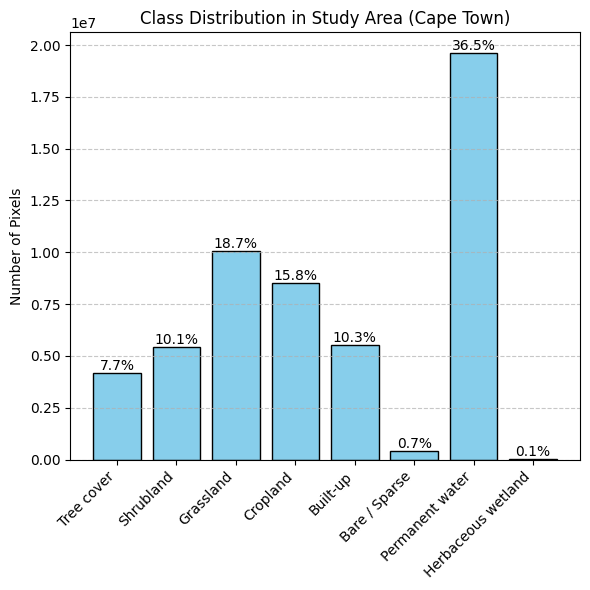

   Class_ID          Class_Name  Pixel_Count  Percentage
0        10          Tree cover      4160621    7.733012
1        20           Shrubland      5455817   10.140289
2        30           Grassland     10067487   18.711630
3        40            Cropland      8504379   15.806406
4        50            Built-up      5550411   10.316103
5        60       Bare / Sparse       394682    0.733564
6        80     Permanent water     19629712   36.484170
7        90  Herbaceous wetland        40259    0.074826


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculating unique values and their pixel counts
unique, counts = np.unique(labeled_map.values, return_counts=True)

class_names = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse",
    80: "Permanent water",
    90: "Herbaceous wetland",
    0:  "No Data / Ocean"
}

df = pd.DataFrame({
    'Class_ID': unique,
    'Pixel_Count': counts
})

df['Class_Name'] = df['Class_ID'].map(class_names)

# Calculating Percentage
total_pixels = counts.sum()
df['Percentage'] = (df['Pixel_Count'] / total_pixels) * 100
# df = df.sort_values('Pixel_Count', ascending=False)

# Plotting the Distribution
plt.figure(figsize=(6, 6))
bars = plt.bar(df['Class_Name'], df['Pixel_Count'], color='skyblue', edgecolor='black')

# Adding percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, 
             f'{yval/total_pixels:.1%}', va='bottom', ha='center')

plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution in Study Area (Cape Town)")
plt.ylabel("Number of Pixels")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(df[['Class_ID', 'Class_Name', 'Pixel_Count', 'Percentage']])

In [ ]:
# Band stacking and normalization for models
import numpy as np
import rioxarray

# re-assign the names to the numbered bands
original_band_names = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12']
sentinel_stack.coords['band'] = original_band_names


# B04=Red, B03=Green, B02=Blue, B08=NIR, B11=SWIR1, B12=SWIR2
custom_6_bands = ['B04', 'B03', 'B02', 'B08', 'B11', 'B12']

# sentinel_stack is the original rioxarray object
s2_6band = sentinel_stack.sel(band=custom_6_bands)


print("--- SAMPLES BEFORE NORMALIZATION (Raw DN) ---")
sample_pre = s2_6band.sel(band='B04').isel(x=slice(500, 502), y=slice(500, 502)).values
print(sample_pre)

# Apply Normalization
s2_norm = s2_6band / 10000.0

# Clip to [0, 1] 
s2_norm = s2_norm.clip(0, 1)

print("\n--- SAMPLES AFTER NORMALIZATION (0.0 - 1.0) ---")
sample_post = s2_norm.sel(band='B04').isel(x=slice(500, 502), y=slice(500, 502)).values
print(sample_post)

print(f"\nFinal Stack Shape: {s2_norm.shape}")

--- SAMPLES BEFORE NORMALIZATION (Raw DN) ---
[[2078 2156]
 [2036 2216]]

--- SAMPLES AFTER NORMALIZATION (0.0 - 1.0) ---
[[0.2078 0.2156]
 [0.2036 0.2216]]

Final Stack Shape: (6, 9336, 5763)


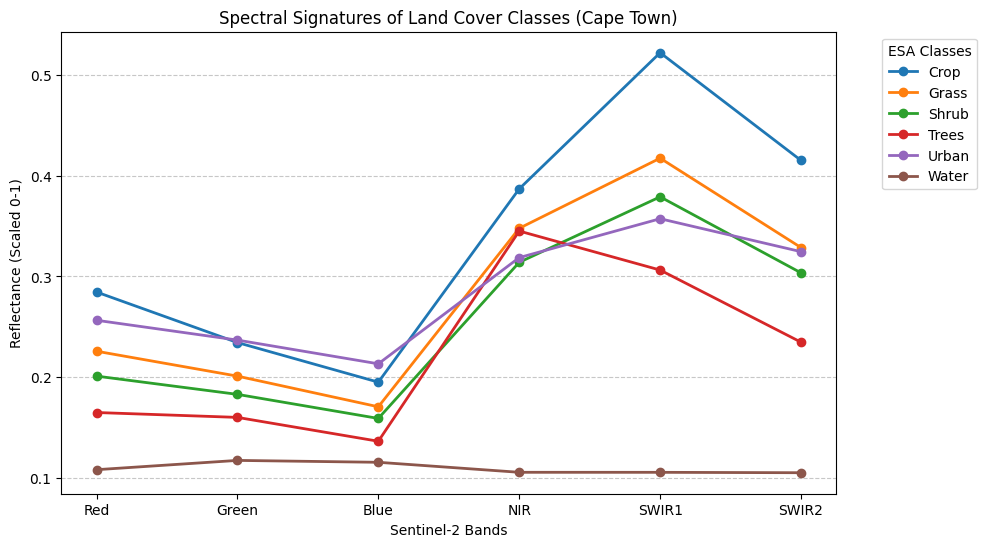

In [ ]:
# How land classes reflect light across different bands.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for sampling
n_samples = 100000  
indices = np.random.choice(s2_norm.x.size * s2_norm.y.size, n_samples, replace=False)

# Flatten bands and labels
flat_data = s2_norm.values.reshape(6, -1).T[indices]
flat_labels = labeled_map.values.flatten()[indices]


df_eda = pd.DataFrame(flat_data, columns=['Red', 'Green', 'Blue', 'NIR', 'SWIR1', 'SWIR2'])
df_eda['Class_ID'] = flat_labels

# Map IDs to names for the plot
class_names = {10: "Trees", 20: "Shrub", 30: "Grass", 40: "Crop", 50: "Urban", 80: "Water", 0: "NoData"}
df_eda['Class_Name'] = df_eda['Class_ID'].map(class_names)

# Calculate Mean Signatures
signature_data = df_eda.groupby('Class_Name')[['Red', 'Green', 'Blue', 'NIR', 'SWIR1', 'SWIR2']].mean().T

# Plotting
plt.figure(figsize=(10, 6))
for column in signature_data.columns:
    if column != "NoData": 
        plt.plot(signature_data.index, signature_data[column], marker='o', label=column, linewidth=2)

plt.title("Spectral Signatures of Land Cover Classes (Cape Town)")
plt.ylabel("Reflectance (Scaled 0-1)")
plt.xlabel("Sentinel-2 Bands")
plt.legend(title="ESA Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

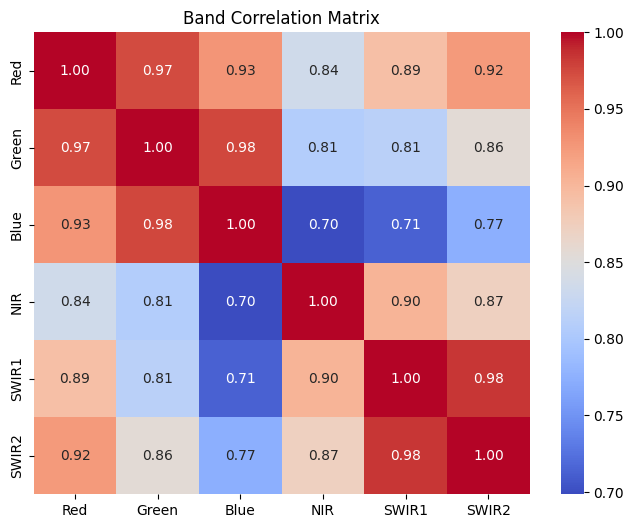

In [ ]:
# Band Correlation Matrix
plt.figure(figsize=(8, 6))

sns.heatmap(df_eda[['Red', 'Green', 'Blue', 'NIR', 'SWIR1', 'SWIR2']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Band Correlation Matrix")
plt.show()

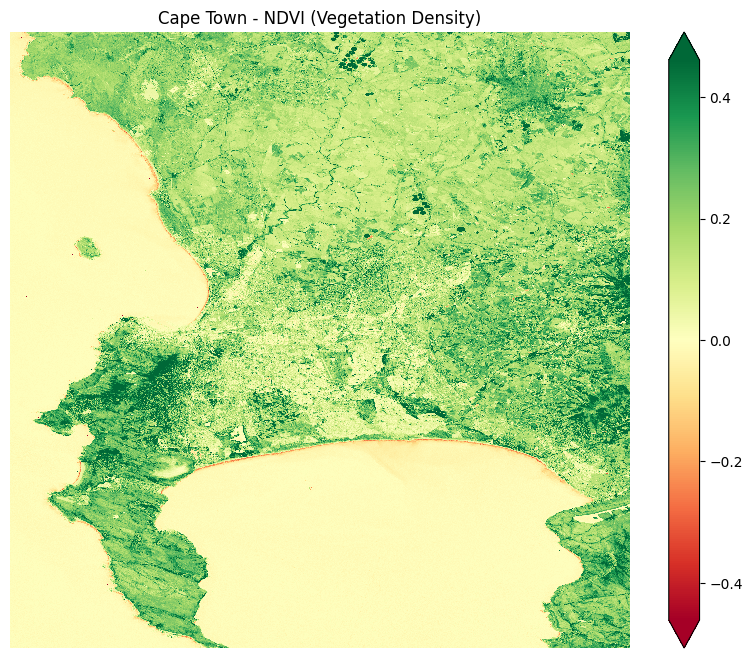

In [ ]:
# Calculate NDVI using the normalized 6-band stack
# NIR is B08, Red is B04
red = s2_norm.sel(band='B04')
nir = s2_norm.sel(band='B08')

ndvi = (nir - red) / (nir + red)

# Visualize the NDVI Map
plt.figure(figsize=(10, 8))
ndvi.plot.imshow(cmap='RdYlGn', robust=True) 
plt.title("Cape Town - NDVI (Vegetation Density)")
plt.axis('off')
plt.show()

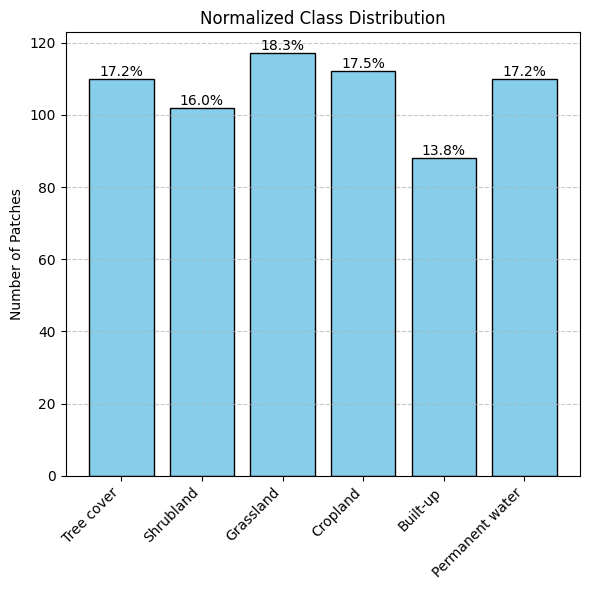

   Class_ID       Class_Name  Patch_Count  Percentage
0        10       Tree cover          110   17.214397
1        20        Shrubland          102   15.962441
2        30        Grassland          117   18.309859
3        40         Cropland          112   17.527387
4        50         Built-up           88   13.771518
5        80  Permanent water          110   17.214397


In [ ]:
# Normalized CLass Distribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_labels = np.load('processed_data/Y_train_labels.npy')

unique, counts = np.unique(y_labels, return_counts=True)

class_names = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse",
    80: "Permanent water",
    90: "Herbaceous wetland",
    0:  "No Data / Ocean"
}

df = pd.DataFrame({
    'Class_ID': unique,
    'Patch_Count': counts
})

df['Class_Name'] = df['Class_ID'].map(class_names).fillna(df['Class_ID'])
total_patches = counts.sum()
df['Percentage'] = (df['Patch_Count'] / total_patches) * 100
# df = df.sort_values('Patch_Count', ascending=False)

plt.figure(figsize=(6, 6))
bars = plt.bar(df['Class_Name'], df['Patch_Count'], color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, 
             f'{yval/total_patches:.1%}', va='bottom', ha='center')

plt.xticks(rotation=45, ha='right')
plt.title("Normalized Class Distribution")
plt.ylabel("Number of Patches")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Printing the table summary
print(df[['Class_ID', 'Class_Name', 'Patch_Count', 'Percentage']])